In [ ]:
import pandas as pd

In [ ]:
# ================= CONFIG =================

OPENROUTER_API_KEY = "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"  # your key

MODEL_NAME = "meta-llama/llama-3.3-70b-instruct:free"

PROMPT_TO_RUN = 3
# 1 = Zero-shot
# 2 = Few-shot
# 3 = Structured reasoning

SAMPLE_SIZE = 200
RANDOM_SEED = 42

TEMPERATURE = 0.2
MAX_TOKENS = 400
SLEEP_TIME = 0.6
headers = {
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
    "Content-Type": "application/json",
    "HTTP-Referer": "http://localhost",
    "X-Title": "Fynd Task 1 Evaluation"
}



In [ ]:
PROMPT_1 = """You are a rating prediction system.

Classify each review into a star rating from 1 to 5.

Return ONLY valid JSON.
The output must be a JSON array.
Each element must be:
{{
  "review_id": <integer>,
  "predicted_stars": <integer 1-5>
}}

Reviews:
{reviews}
"""
PROMPT_2 = """You are a rating prediction system.

Examples:
Review: "Amazing food and service!" → 5
Review: "Terrible experience and rude staff." → 1

Now classify the following reviews.

Return ONLY valid JSON.
The output must be a JSON array.
Each element must be:
{{
  "review_id": <integer>,
  "predicted_stars": <integer 1-5>
}}

Reviews:
{reviews}
"""
PROMPT_3 = """You are an expert review classifier.

Classify each review into a star rating (1–5).

Return ONLY valid JSON.
The output must be a JSON array.
Each element must be:
{{
  "review_id": <integer>,
  "predicted_stars": <integer 1-5>
}}

Reviews:
{reviews}
"""




## 3. Prompt Selector

In [ ]:
if PROMPT_TO_RUN == 1:
    PROMPT = PROMPT_1
    APPROACH = "Zero-Shot"
    OUTPUT_FILE = "approach_1_zero_shot.csv"

elif PROMPT_TO_RUN == 2:
    PROMPT = PROMPT_2
    APPROACH = "Few-Shot"
    OUTPUT_FILE = "approach_2_few_shot.csv"

elif PROMPT_TO_RUN == 3:
    PROMPT = PROMPT_3
    APPROACH = "Structured"
    OUTPUT_FILE = "approach_3_structured.csv"

else:
    raise ValueError("Invalid PROMPT_TO_RUN")


## 4. Safe LLM Call Function (NO HANGS)

In [ ]:
import re

def extract_json(text):
    match = re.search(r"\[\s*{.*}\s*\]", text, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group())
    except:
        return None


def call_llm(prompt):
    payload = {
        "model": MODEL_NAME,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": TEMPERATURE,
        "max_tokens": MAX_TOKENS
    }

    try:
        r = requests.post(
            "https://openrouter.ai/api/v1/chat/completions",
            headers=headers,
            json=payload,
            timeout=30
        )

        data = r.json()

        # Provider / routing error
        if "choices" not in data:
            return None, False, str(data)

        choice = data["choices"][0]

        # Truncated output
        if choice.get("finish_reason") == "length":
            return None, False, choice.get("message", {}).get("content", "")

        raw_text = choice["message"]["content"]

        parsed = extract_json(raw_text)
        if parsed is None:
            return None, False, raw_text

        return parsed, True, raw_text

    except Exception as e:
        return None, False, str(e)


## 5. Prediction Loop (STABLE)

In [ ]:
df = pd.read_csv("/content/yelp.csv")
sample_df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_SEED)

BATCH_SIZE = 5
results = []

print(f"\nRunning {APPROACH} Prompt")

for start in range(0, len(sample_df), BATCH_SIZE):
    batch = sample_df.iloc[start:start+BATCH_SIZE]

    reviews_block = "\n".join(
        [f"{idx}. {str(row['text'])[:1000]}" for idx, row in batch.iterrows()]
    )
    prompt = PROMPT.format(reviews=reviews_block)
    outputs, valid, raw_response = call_llm(prompt)

    if valid:
        for item in outputs:
            idx = item.get("review_id")

            try:
                idx = int(idx)
            except:
                idx = None

            predicted = item.get("predicted_stars")

            if idx is None or idx not in sample_df.index:
                results.append({
                    "review": None,
                    "actual_stars": None,
                    "predicted_stars": None,
                    "raw_response": raw_response,
                    "valid_json": False,
                    "error": "Invalid or missing review_id"
                })
                continue

            results.append({
                "review": str(sample_df.loc[idx, "text"])[:600],
                "actual_stars": sample_df.loc[idx, "stars"],
                "predicted_stars": predicted,
                "raw_response": raw_response,
                "valid_json": predicted is not None,
                "error": None
            })

    else:
        for _, row in batch.iterrows():
            results.append({
                "review": str(row["text"])[:600],
                "actual_stars": row["stars"],
                "predicted_stars": None,
                "raw_response": raw_response,
                "valid_json": False,
                "error": "LLM failure"
            })

    print(f"Processed {min(start+BATCH_SIZE, SAMPLE_SIZE)}/{SAMPLE_SIZE}")
    time.sleep(SLEEP_TIME)

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ Saved results to {OUTPUT_FILE}")




Running Structured Prompt
Processed 5/200
Processed 10/200
Processed 15/200
Processed 20/200
Processed 25/200
Processed 30/200
Processed 35/200
Processed 40/200
Processed 45/200
Processed 50/200
Processed 55/200
Processed 60/200
Processed 65/200
Processed 70/200
Processed 75/200
Processed 80/200
Processed 85/200
Processed 90/200
Processed 95/200
Processed 100/200
Processed 105/200
Processed 110/200
Processed 115/200
Processed 120/200
Processed 125/200
Processed 130/200
Processed 135/200
Processed 140/200
Processed 145/200
Processed 150/200
Processed 155/200
Processed 160/200
Processed 165/200
Processed 170/200
Processed 175/200
Processed 180/200
Processed 185/200
Processed 190/200
Processed 195/200
Processed 200/200

✅ Saved results to approach_3_structured.csv


In [ ]:
sample_df.to_csv("sample_df.csv", index=False)

In [ ]:
results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅ Saved results to {OUTPUT_FILE}")


✅ Saved results to approach_1_zero_shot.csv


In [ ]:
results_1 = pd.read_csv("/content/approach_1_zero_shot.csv")
results_2 = pd.read_csv("/content/approach_2_few_shot.csv")
results_3 = pd.read_csv("/content/approach_3_structured.csv")

results_map = {
    "Approach 1 – Zero-Shot": results_1,
    "Approach 2 – Few-Shot": results_2,
    "Approach 3 – Structured Reasoning": results_3
}



In [ ]:
def evaluate_results(df, name):
    valid_df = df[df["valid_json"] == True].copy()

    total = len(df)
    valid = len(valid_df)

    if valid == 0:
        return {
            "Approach": name,
            "Accuracy (%)": 0,
            "JSON Validity (%)": 0,
            "MAE": None,
            "±1 Accuracy (%)": 0
        }

    acc = accuracy_score(valid_df["actual_stars"], valid_df["predicted_stars"]) * 100
    mae = mean_absolute_error(valid_df["actual_stars"], valid_df["predicted_stars"])

    # ±1 tolerance accuracy (VERY IMPORTANT)
    tolerant_acc = np.mean(
        np.abs(valid_df["actual_stars"] - valid_df["predicted_stars"]) <= 1
    ) * 100

    return {
        "Approach": name,
        "Accuracy (%)": round(acc, 2),
        "JSON Validity (%)": round((valid / total) * 100, 2),
        "MAE": round(mae, 3),
        "±1 Accuracy (%)": round(tolerant_acc, 2)
    }


In [ ]:
metrics = []

for name, df in results_map.items():
    metrics.append(evaluate_results(df, name))

comparison_df = pd.DataFrame(metrics)
comparison_df


,Approach,Accuracy (%),JSON Validity (%),MAE,±1 Accuracy (%)
0,Approach 1 – Zero-Shot,61.24,64.50,0.442,95.35
1,Approach 2 – Few-Shot,60.00,97.01,0.436,96.41
2,Approach 3 – Structured Reasoning,65.00,99.50,0.385,96.50


In [ ]:
def per_class_accuracy(df):
    valid_df = df[df["valid_json"] == True]
    acc = {}

    for star in range(1, 6):
        subset = valid_df[valid_df["actual_stars"] == star]
        if len(subset) > 0:
            acc[star] = round(
                (subset["actual_stars"] == subset["predicted_stars"]).mean() * 100, 2
            )
        else:
            acc[star] = None

    return acc


for name, df in results_map.items():
    print(f"\n{name}")
    print(per_class_accuracy(df))



Approach 1 – Zero-Shot
{1: np.float64(85.71), 2: np.float64(46.15), 3: np.float64(38.89), 4: np.float64(48.0), 5: np.float64(88.24)}

Approach 2 – Few-Shot
{1: np.float64(76.47), 2: np.float64(35.29), 3: np.float64(36.36), 4: np.float64(48.68), 5: np.float64(94.23)}

Approach 3 – Structured Reasoning
{1: np.float64(88.89), 2: np.float64(47.06), 3: np.float64(42.42), 4: np.float64(53.16), 5: np.float64(94.34)}


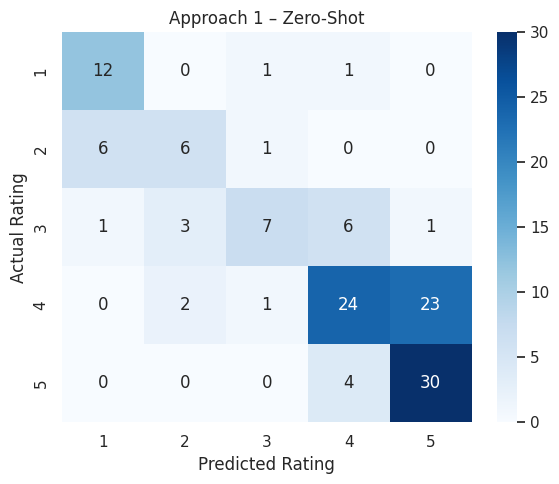

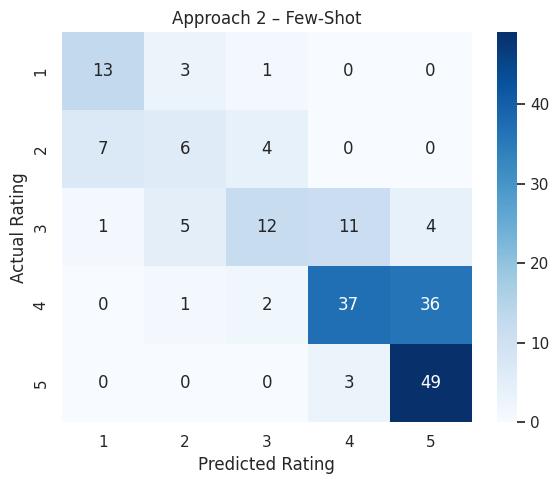

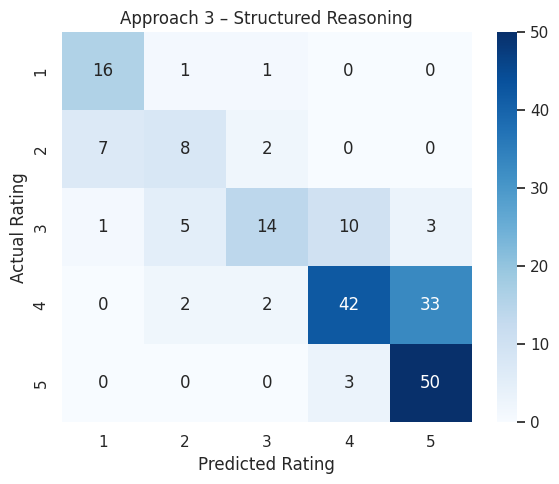

In [ ]:
def plot_confusion(df, title):
    valid_df = df[df["valid_json"] == True]

    cm = confusion_matrix(
        valid_df["actual_stars"],
        valid_df["predicted_stars"],
        labels=[1, 2, 3, 4, 5]
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=[1, 2, 3, 4, 5],
        yticklabels=[1, 2, 3, 4, 5]
    )
    plt.title(title)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.tight_layout()
    plt.show()


for name, df in results_map.items():
    plot_confusion(df, name)


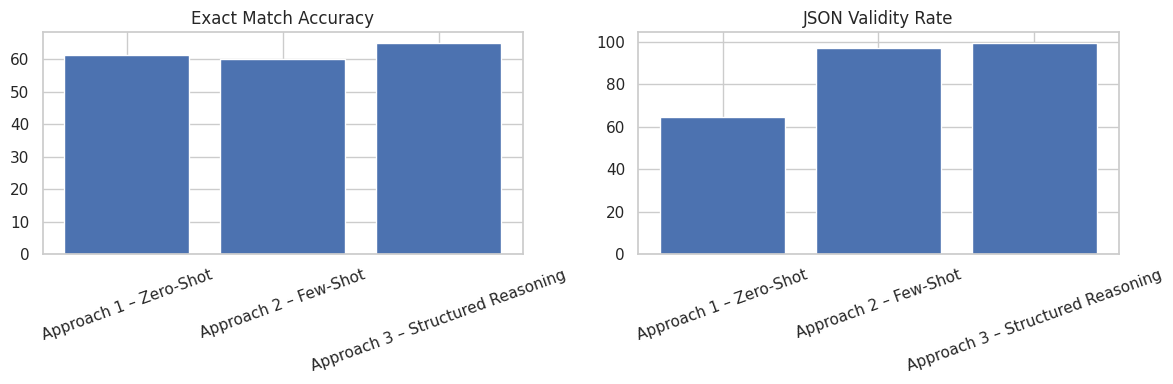

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(comparison_df["Approach"], comparison_df["Accuracy (%)"])
plt.xticks(rotation=20)
plt.title("Exact Match Accuracy")

plt.subplot(1, 2, 2)
plt.bar(comparison_df["Approach"], comparison_df["JSON Validity (%)"])
plt.xticks(rotation=20)
plt.title("JSON Validity Rate")

plt.tight_layout()
plt.show()


In [ ]:
comparison_df.to_csv("task1_final_metrics.csv", index=False)
print("✅ Saved evaluation metrics to task1_final_metrics.csv")


✅ Saved evaluation metrics to task1_final_metrics.csv
